#The Problem with Simple Word Vectors

One word, many meanings — static embeddings are stuck with just one vector
per word.

In Day 17 we saw how GloVe and Word2Vec give each word a fixed vector. 'King' always has the
same 300 numbers. But what about the word 'bank'? It means completely different things depending
on its context — and a fixed vector can't capture that. This is called the **polysemy problem.**

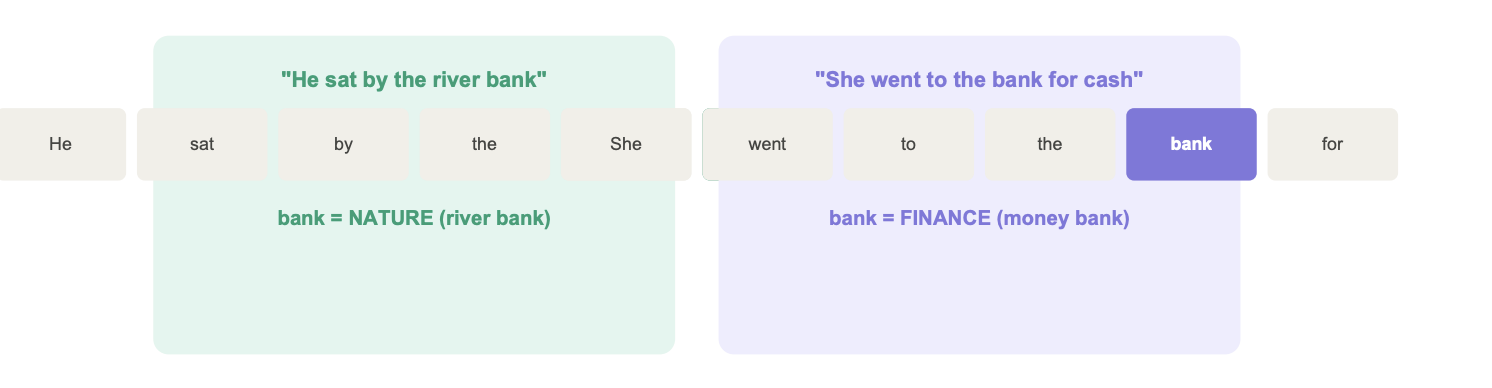

**What static embeddings miss**

GloVe and Word2Vec compute ONE vector for 'bank' by averaging all the contexts it appears in
across the training corpus. The result is a blurry average of both meanings — neither river-bank nor
money-bank. When your model sees 'river bank' it gets the same vector as 'money bank'. This
causes errors in downstream tasks.

**The solution: context-aware embeddings**
Instead of giving each word a fixed vector, we want a model that reads the ENTIRE
sentence and produces a DIFFERENT vector for 'bank' depending on whether it appears
near 'river' or near 'money'.
This is exactly what the Transformer architecture achieves — through a mechanism called
Self-Attention, which we'll explore in Section 02.

#The Attention Mechanism

Teaching the model which words to focus on when understanding each word.
Imagine reading the sentence: 'She picked up the cup and drank from it.' When you reach 'it', your

brain instantly knows 'it = cup'. You didn't re-read every word with equal effort — your attention
jumped straight to 'cup'. The Attention Mechanism in neural networks does exactly the same thing,
mathematically.

**Real-life analogy — attention as a spotlight**

Think of a concert. When the guitarist is soloing, your ears (attention) naturally focus on the guitar
and tune out the drums. When the singer starts, your attention shifts. The Attention Mechanism gives
every word in a sentence its own spotlight that can move around and focus on the most relevant other
words.

**How Self-Attention works — step by step**

For every word in the sentence, Self-Attention asks three questions using three learned vectors —
Query (Q), Key (K), and Value (V):

**Query (Q)** --> What am I looking for? — When processing 'it', Q asks 'what object was
mentioned earlier?'

**Key (K)** --> What do I offer? — 'cup' broadcasts that it's a physical object that can be
referred to.

**Value (V)** --> What information do I actually carry? — 'cup' provides its rich semantic
meaning.

The attention score between two words = dot product of Q and K, scaled and softmaxed. High score
= strong attention (the word 'it' pays lots of attention to 'cup'). The model then takes a weighted sum
of Value vectors.

**Visualising attention — colour-coded attention map**

Below: darker cells mean the row-word pays more attention to the column-word. Look at the last row
('it') — it has a dark cell under 'cup' (0.40), correctly learning that 'it' refers to 'cup'.

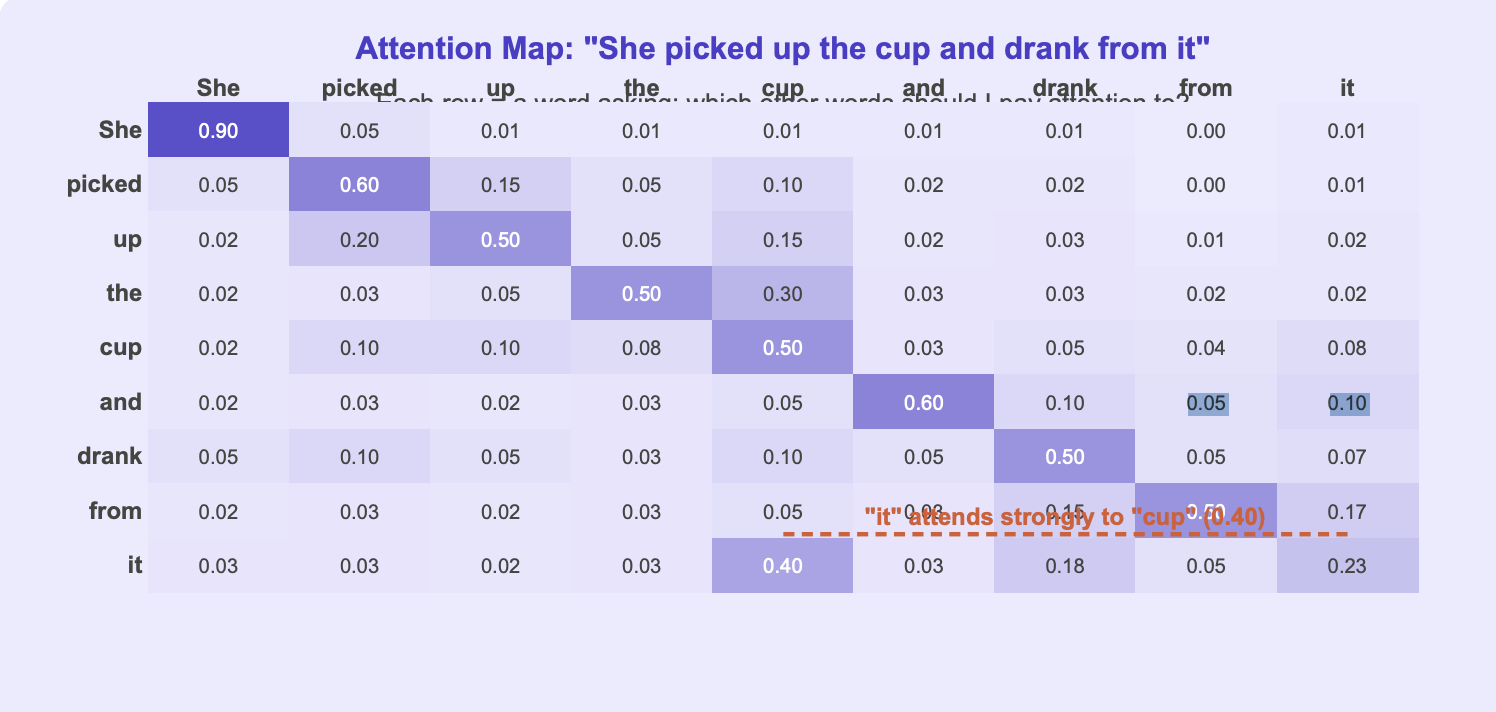

**Multi-Head Attention — looking from multiple angles**

BERT doesn't just run attention once. It runs it 12 times in parallel, each with different Q/K/V weight
matrices. These are called 'heads'. Each head learns to focus on different types of relationships:

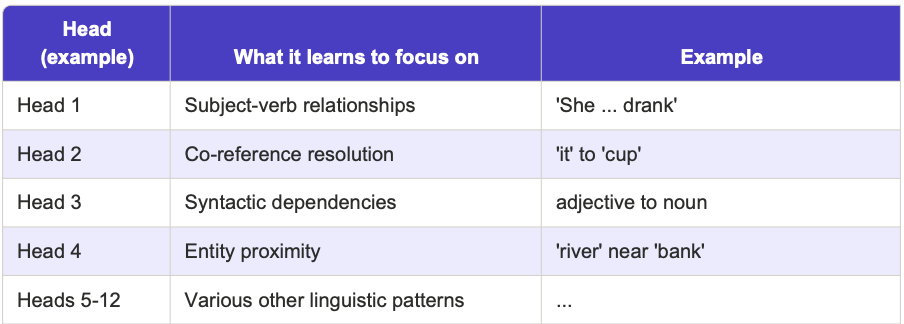

Why attention is better than RNNs
Before Transformers, RNNs (Recurrent Neural Networks) processed text word by word, left
to right. To connect 'it' to 'cup', the signal had to travel through 4 intermediate words —
getting weaker each step (the 'vanishing gradient' problem).
Attention connects ANY two words DIRECTLY in one step, regardless of distance. This is
why Transformers handle long documents so much better than RNNs.

RNNs (Recurrent Neural Networks) are networks that read sequences one word at a time, left to right, and carry a "memory" from each step to the next. Think of it like reading a sentence while only keeping notes in a tiny notebook — by the time you reach the end, early details can be forgotten.

Real-life example: Predicting the next word as you type
When you type "I want to eat a hot ___", an RNN reads each word one by one, passing its memory forward. But by the time it reaches "hot", the early context ("I want to eat") may have faded — this is called the vanishing gradient problem.

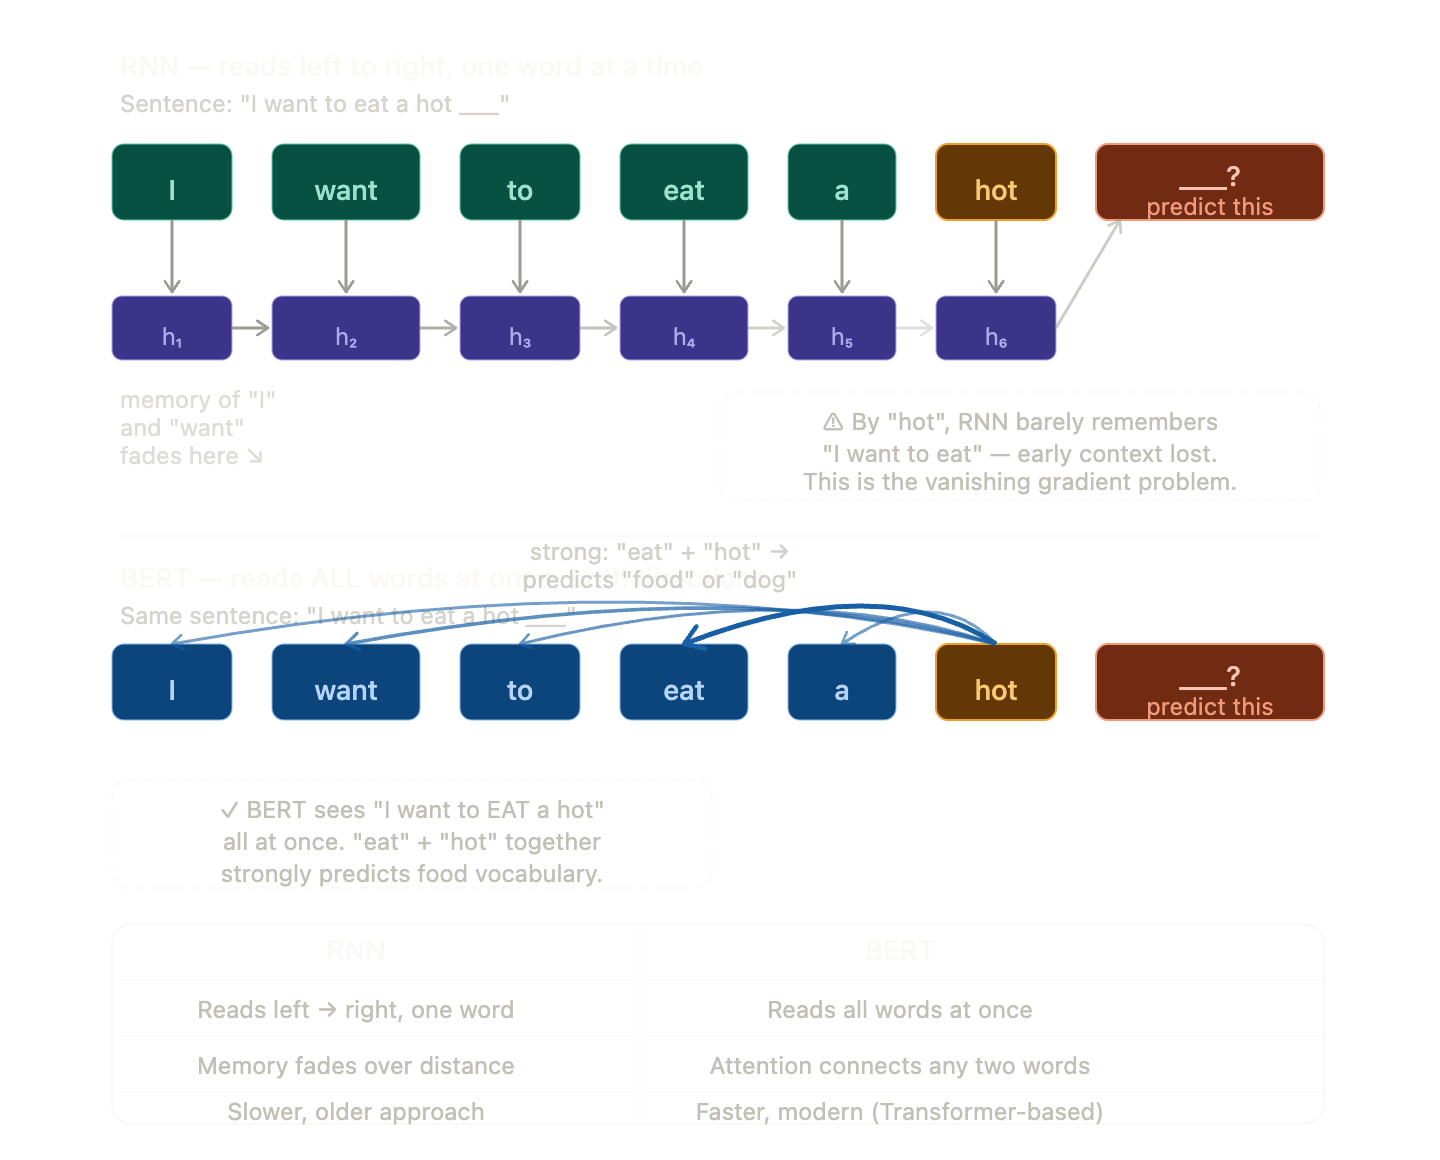

#Transformers — The Architecture that Changed NLP

A **Transformer** is made up of multiple layers of **Multi-Head Attention** and **Feed-Forward Networks**.
Each layer helps words better understand their relationship with other words in the sentence.
As the data passes through the layers, the word representations become more context-aware.
The model gradually learns deeper meanings and connections between words.
In **BERT-base**, there are **12 such layers**.
After all 12 layers, the model has a rich understanding of each word in the context of the entire sentence.


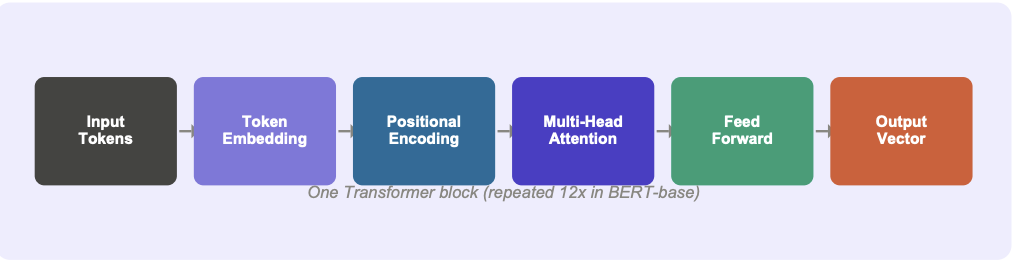

**Key components**

**Token Embedding** --> Each word (token) is converted to a 768-D vector. Like
Word2Vec but learned jointly with the model.

**Positional Encoding** --> 'She loves him' is not 'He loves her'. Since Attention has no
built-in notion of order, we add a sinusoidal position signal to
each token embedding to encode word order.

**Multi-Head Attention** --> 12 attention heads run in parallel. Each learns different linguistic
relationships. Outputs are concatenated and linearly projected
back to 768-D.

**Feed-Forward Network** A simple 2-layer fully connected network applied to each
position. Adds non-linearity and extra capacity. Output is still
768-D.

**Layer Norm +
Residuals** -->
Each sub-layer has a residual (skip) connection and layer
normalisation, ensuring stable training even with 12+ stacked
layers.

**BERT-base vs BERT-large vs modern models**

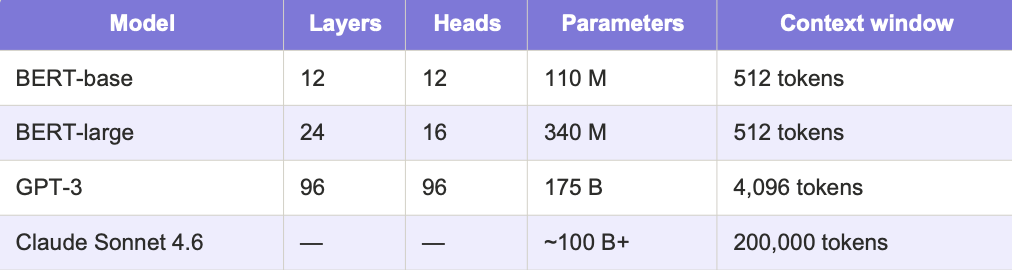

#BERT — A Pre-trained Language Brain

Bidirectional Encoder Representations from Transformers — Google AI, 2018.
BERT took the Transformer encoder and pre-trained it on a massive scale: all of English Wikipedia
(2.5 billion words) plus BookCorpus (800 million words). The result is a model that deeply
understands English grammar, facts, relationships, and nuance — before you show it a single
labelled example. You then fine-tune this pre-trained brain on your specific task.

**What makes BERT 'Bidirectional'?**

Previous models like GPT-1 read text left-to-right only. BERT reads the ENTIRE sentence
simultaneously — left and right context at every position. When understanding the word 'bank' in
position 5, BERT can see all words before AND after it. This bidirectionality is why BERT dramatically
outperformed earlier models on tasks like question-answering.

**How BERT was pre-trained — two clever tasks**

**Task 1: Masked Language
Model (MLM)** --->
15% of input tokens are randomly replaced with [MASK].
BERT must predict the original word. Example: 'The
[MASK] sat on the mat' predicts 'cat'. This forces BERT to
understand full bidirectional context.

**Task 2: Next Sentence
Prediction (NSP)** --->
Given two sentences A and B, predict if B actually follows
A in the original text. This teaches BERT about
inter-sentence relationships — vital for QA and NLI tasks.

**Pre-training vs Fine-tuning — the two-phase approach**

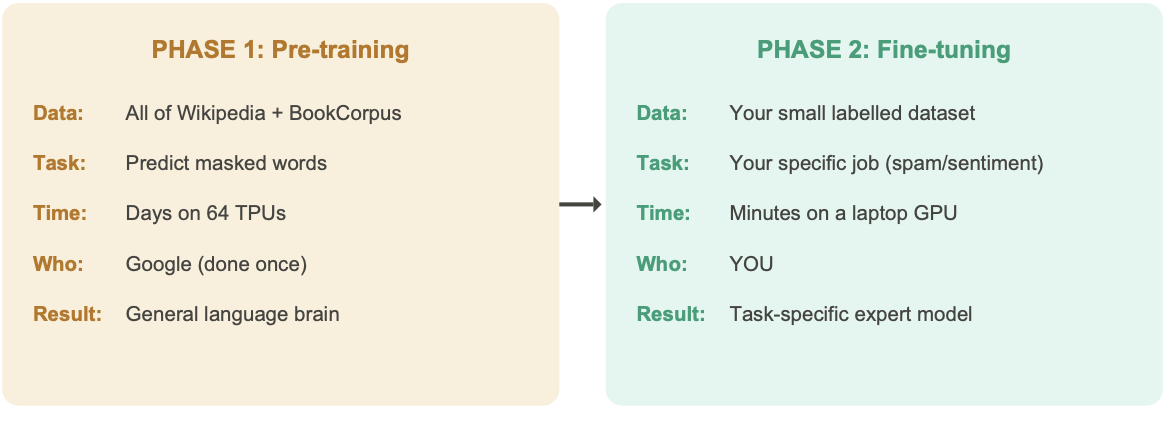

**What can you fine-tune BERT for?**

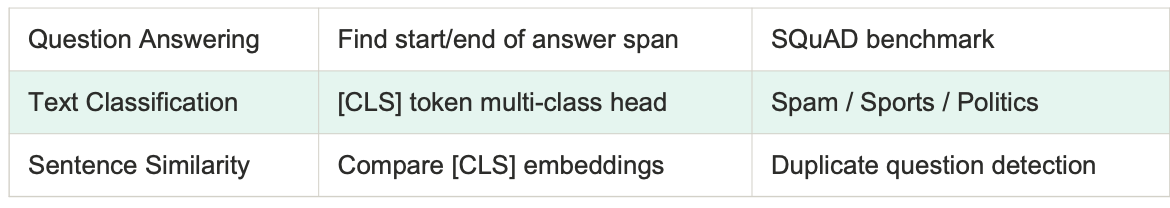
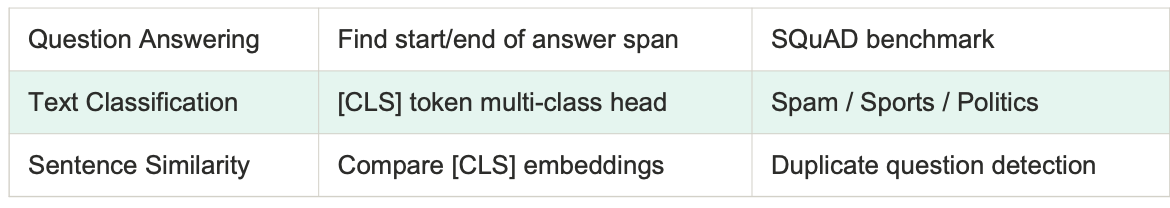

**Real-life analogy — BERT as a medical graduate**

A fresh medical graduate has spent 5 years studying all of human anatomy and medicine
(pre-training on Wikipedia). You then hire them and give them 2 weeks of specific training
on dermatology (fine-tuning on your dataset). They become an excellent dermatologist far
faster than training someone from scratch — because their general knowledge (the BERT
base) is already world-class.
That's exactly what transfer learning with BERT does for NLP.

#HuggingFace Pipelines — One Line of Code

HuggingFace is the 'GitHub for AI models' — a platform with 500,000+ pre-trained models freely
available. Their pipeline() function wraps any model with automatic tokenisation, inference, and
post-processing. What used to take 200 lines of code now takes 3.

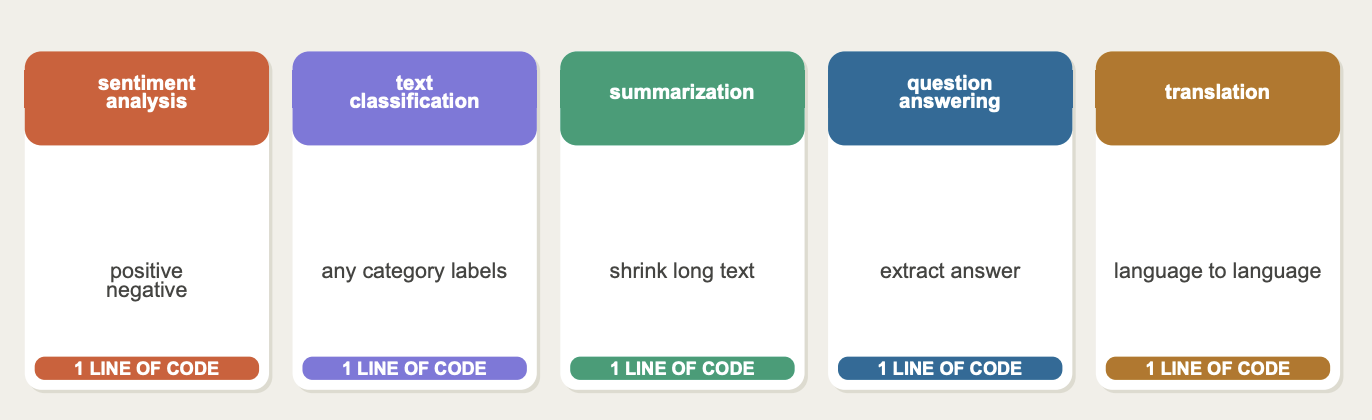

In [ ]:
# Install HuggingFace Transformers
!pip install transformers torch
from transformers import pipeline
# The pipeline() function handles everything:
# 1. Downloads the model weights (~400 MB, cached after first run)
# 2. Loads the tokeniser (converts text to token IDs)
# 3. Runs inference through the Transformer model
# 4. Post-processes and returns human-readable results

**Pipeline 1 — Sentiment Analysis**
Classifies text as POSITIVE or NEGATIVE with a confidence score. Uses DistilBERT fine-tuned on
the SST-2 movie reviews dataset by default.

In [ ]:
from transformers import pipeline
senti = pipeline('sentiment-analysis')
reviews = [
'This movie was absolutely breathtaking! A masterpiece.',
'Terrible acting, boring plot. Wasted 2 hours of my life.',
'It was okay. Nothing special but not bad either.',
'Shah Rukh Khan was brilliant. Loved every minute!',
'Ram is more attractive than jayanth ani evaro chepparu',
'KSRM is a great college in asia',
'charan is bad '
]
results = senti(reviews) # pass a list — processes all at once
for review, result in zip(reviews, results):
  label = result['label'] # 'POSITIVE' or 'NEGATIVE'
  score = result['score'] # confidence: 0.0 to 1.0
  print(f'{label} ({score:.1%}) | {review[:50]}...')
# POSITIVE (99.8%) | This movie was absolutely breathtaking! A masterp...
# NEGATIVE (99.9%) | Terrible acting, boring plot. Wasted 2 hours of m...
# NEGATIVE (55.2%) | It was okay. Nothing special but not bad either....
# POSITIVE (99.1%) | Shah Rukh Khan was brilliant. Loved every minute!.

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

POSITIVE (100.0%) | This movie was absolutely breathtaking! A masterpi...
NEGATIVE (100.0%) | Terrible acting, boring plot. Wasted 2 hours of my...
POSITIVE (99.6%) | It was okay. Nothing special but not bad either....
POSITIVE (100.0%) | Shah Rukh Khan was brilliant. Loved every minute!...
POSITIVE (100.0%) | Ram is more attractive than jayanth ani evaro chep...
POSITIVE (100.0%) | KSRM is a great college in asia...
NEGATIVE (100.0%) | charan is bad ...


**Pipeline 2 — Text Classification (Zero-shot)**
Zero-shot classification lets you define your OWN category labels — the model was never trained on
your specific categories but still classifies correctly by understanding the semantic meaning of your
labels.

In [ ]:
from transformers import pipeline
# Zero-shot: classify without any task-specific training
classifier = pipeline('zero-shot-classification',
model='facebook/bart-large-mnli')
text = 'ksrm is a college of engineering . in aiml we have best students in non crt but cse are worst except few(nen itey aswitha ni analey)'
labels = ['technology','course','computer science','artificial intellignece']
result = classifier(text, candidate_labels=labels)
for label, score in zip(result['labels'], result['scores']):
   print(f'{label:15} {score:.1%}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

technology      57.7%
course          28.7%
artificial intellignece 10.7%
computer science 2.9%


**Pipeline 3 — Summarisation**

In [ ]:
import transformers
print(transformers.__file__)
print(transformers.__version__)

/usr/local/lib/python3.12/dist-packages/transformers/__init__.py
5.10.1


In [ ]:
!pip install --force-reinstall transformers==4.44.2 tokenizers==0.19.1 --break-system-packages

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from transformers import pipeline

summariser = pipeline(
    task="summarization",
    model="facebook/bart-large-cnn"
)

long_text = """
The Indian Space Research Organisation (ISRO) successfully launched its
latest Earth observation satellite from the Satish Dhawan Space Centre in
Sriharikota. The satellite carries high-resolution cameras capable of
imaging at 0.5-metre resolution, making it among the most advanced Earth
observation tools deployed. The data will be used for agriculture
monitoring, disaster management, and urban planning.
"""

summary = summariser(
    long_text,
    max_length=20,
    min_length=15,
    do_sample=False,
    truncation=True
)

print(summary[0]["summary_text"])

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


The Indian Space Research Organisation (ISRO) successfully launched its latest Earth observation satellite.


**Pipeline 4 — Question Answering**
Extractive QA: given a context passage and a question, the model finds and returns the exact span of
text that answers the question.

In [ ]:
from transformers import pipeline
qa = pipeline('question-answering',
model='deepset/bert-base-cased-squad2')
context = '''
Sachin Tendulkar played for India for 24 years from 1989 to 2013.
He scored 100 international centuries and 15,921 Test runs.
He was awarded the Bharat Ratna in 2014.
'''
questions = [
'How many international centuries did Sachin score?',
'When did Sachin Tendulkar retire?',
'What award did he receive in 2014?',
]
for q in questions:
  answer = qa(question=q, context=context)
  print(f'Q: {q}')
  print(f'A: {answer["answer"]} (confidence: {answer["score"]:.1%})')
# Q: How many international centuries did Sachin score?
# A: 100 (confidence: 94.2%)

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Q: How many international centuries did Sachin score?
A: 100 (confidence: 95.2%)
Q: When did Sachin Tendulkar retire?
A: 2013 (confidence: 67.0%)
Q: What award did he receive in 2014?
A: Bharat Ratna (confidence: 97.4%)


**Pipeline 5 — Translation**

In [ ]:
from transformers import pipeline
# Helsinki-NLP models for 1000+ language pairs
# Model naming: Helsinki-NLP/opus-mt-{source}-{target}
en_hi = pipeline('translation',
model='Helsinki-NLP/opus-mt-en-te')
texts = [
'Machine learning is changing the world.',
'I love cricket and Bollywood movies.',
]
for text in texts:
  translated = en_hi(text)[0]['translation_text']
  print(f'EN: {text}')
  print(f'HI: {translated}')
# EN: Machine learning is changing the world.
# HI: mshyn lrnng duniya bdl rhi hai.
# For French: pipeline('translation', model='Helsinki-NLP/opus-mt-en-fr')

OSError: Helsinki-NLP/opus-mt-en-te is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

 English → French

pipeline('translation',
         model='Helsinki-NLP/opus-mt-en-fr')

 English → German

pipeline('translation',
         model='Helsinki-NLP/opus-mt-en-de')

 English → Telugu

pipeline('translation',
         model='Helsinki-NLP/opus-mt-en-te')

#Going Further — Fine-tuning BERT (Saturday-Sunday Task)

When the default pipeline isn't enough, train BERT on your own labelled data.
The pipeline() function uses models already fine-tuned on generic datasets. For domain-specific
tasks — medical text, legal documents, Hinglish slang, product reviews in a niche category — you'll
get better results by fine-tuning BERT on your own data. Here's a minimal working example:

Fine-tuning with HuggingFace Trainer API — Part 1: Setup

In [ ]:
from transformers import (AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments, Trainer)
from datasets import Dataset
# --- Step 1: Prepare your labelled dataset ---
texts = ['Great film!', 'Terrible movie.', 'Average, nothing special.',
'Best film of the year!', 'Waste of time and money.']
labels = [1, 0, 0, 1, 0] # 1 = positive, 0 = negative
# --- Step 2: Load tokeniser ---
# 'bert-base-uncased' = lowercase BERT, 110M parameters
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
def tokenise(batch):
# padding=True: pad shorter sequences to the longest in the batch
# truncation=True: cut sequences longer than max_length
  return tokenizer(batch['text'], padding=True,
truncation=True, max_length=128)
dataset = Dataset.from_dict({'text': texts, 'label': labels})
dataset = dataset.map(tokenise, batched=True)
# --- Step 3: Load pre-trained BERT + classification head ---
# num_labels=2 adds a 2-class head on top of BERT's [CLS] output
model = AutoModelForSequenceClassification.from_pretrained(
'bert-base-uncased', num_labels=2
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# --- Step 4: Define training configuration ---
args = TrainingArguments(
output_dir = './results',
num_train_epochs = 3, # 3 passes through training data
per_device_train_batch_size = 4, # process 4 examples at a time
learning_rate = 2e-5, # small LR — avoid forgetting pre-training
logging_steps = 10,
save_strategy = 'no',
)
# --- Step 5: Train ---
trainer = Trainer(
model = model,
args = args,
train_dataset = dataset,
)
trainer.train() # fine-tunes BERT on your labelled data
# --- Step 6: Save and reload as a pipeline ---
model.save_pretrained('./my_sentiment_model')
tokenizer.save_pretrained('./my_sentiment_model')
# Use your custom fine-tuned model exactly like any other pipeline
from transformers import pipeline
my_pipeline = pipeline('sentiment-analysis', model='./my_sentiment_model')
print(my_pipeline('This Bollywood film was a pure delight!'))
# [{'label': 'LABEL_1', 'score': 0.97}] -> LABEL_1 = positive

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.


wandb: Paste your API key and hit enter: ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 1.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


[{'label': 'LABEL_1', 'score': 0.6326547861099243}]


#Lab — Movie Review Sentiment Analyser

Part A — Build the review dataset

In [ ]:
import pandas as pd
from transformers import pipeline
reviews_data = [
# Bollywood
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'An absolute masterpiece! Makes you laugh and cry. '
'Aamir Khan delivers one of his finest performances ever.'},
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'Overrated and preachy. The message was fine but '
'execution felt too theatrical and unrealistic.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Incredibly inspiring! Geeta and Babita brought tears '
'to my eyes. Best sports film ever made in India.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Good film but very long. Some scenes dragged unnecessarily.'},
# Hollywood
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Mind-bending and visually stunning. Nolan at his absolutebest.'},
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Too complicated. I had no idea what was happening half thetime.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'Perfect film. The class commentary is brilliant. Deserved everyOscar.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'I expected more from an Oscar winner. Ending felt rushed.'},
]
df = pd.DataFrame(reviews_data)

Part B — Analyse sentiment

In [ ]:
# Load once — not inside a loop (that would reload weights every iteration)
sentiment = pipeline('sentiment-analysis',
model='distilbert-base-uncased-finetuned-sst-2-english')
# Batch all reviews at once — faster than one-by-one
results = sentiment(df['review'].tolist())
df['sentiment'] = [r['label'] for r in results] # POSITIVE / NEGATIVE
df['confidence'] = [r['score'] for r in results] # 0.0 to 1.0
# sentiment_score: 1.0 = very positive, 0.0 = very negative
df['sentiment_score'] = df['confidence'].where(
df['sentiment'] == 'POSITIVE',
1 - df['confidence']
)
print(df[['movie','sentiment','confidence']].to_string(index=False))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


    movie sentiment  confidence
 3 Idiots  POSITIVE    0.999879
 3 Idiots  NEGATIVE    0.999016
   Dangal  POSITIVE    0.999878
   Dangal  NEGATIVE    0.992343
Inception  POSITIVE    0.999849
Inception  NEGATIVE    0.999590
 Parasite  POSITIVE    0.999857
 Parasite  NEGATIVE    0.998913


Part C — Visualise results

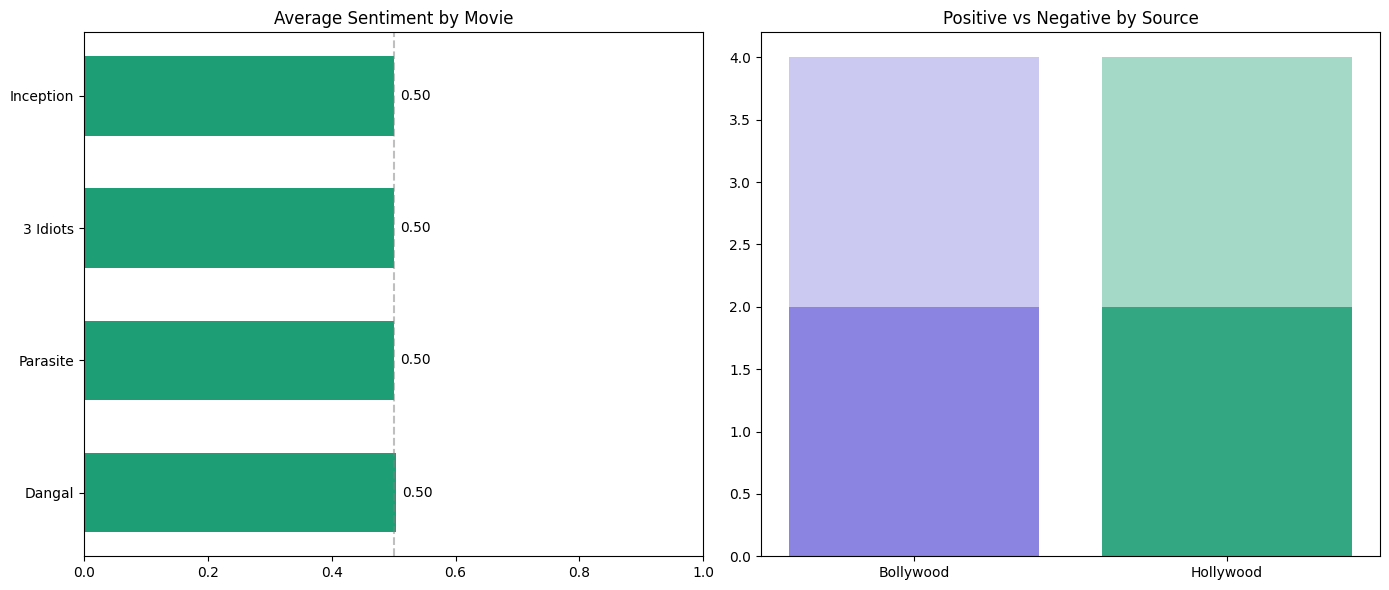

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Chart 1: Average sentiment score per movie
ax1 = axes[0]
movie_scores =df.groupby('movie')['sentiment_score'].mean().sort_values(ascending=False)
colours = ['#1D9E75' if v >= 0.5 else '#D85A30' for v in
movie_scores.values]
bars = ax1.barh(movie_scores.index, movie_scores.values, color=colours,
height=0.6)
ax1.set_xlim(0, 1)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Average Sentiment by Movie')
for bar, val in zip(bars, movie_scores.values):
  ax1.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}',
  va='center')
# Chart 2: Positive vs Negative split by source
  ax2 = axes[1]
for source, colour in [('Bollywood','#7F77DD'), ('Hollywood','#1D9E75')]:
  subset = df[df['source'] == source]
  pos = (subset['sentiment']=='POSITIVE').sum()
  neg = (subset['sentiment']=='NEGATIVE').sum()
  ax2.bar(source, pos, color=colour, alpha=0.9)
  ax2.bar(source, neg, bottom=pos, color=colour, alpha=0.4)
  ax2.set_title('Positive vs Negative by Source')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Part D — Predict on new user input

In [ ]:
def analyse_review(review_text, movie_name='Unknown'):
  result = sentiment(review_text)[0]
  label = result['label']
  conf = result['score']
  if label == 'POSITIVE':
    score = conf
    verdict = 'LOVED IT' if conf > 0.95 else 'LIKED IT'
  else:
    score = 1 - conf
    verdict = 'HATED IT' if conf > 0.95 else 'DISLIKED IT'
  print(f'Movie : {movie_name}')
  print(f'Verdict : {verdict}')
  print(f'Score : {score:.1%} positive')
  print(f'Review : {review_text[:80]}...')
  return {'movie': movie_name, 'verdict': verdict, 'score': score}
analyse_review(
'Rajkummar Rao was phenomenal. A raw, honest performance. '
'Easily the best Hindi film of the decade.',
'Stree'
)

Movie : Stree
Verdict : LOVED IT
Score : 100.0% positive
Review : Rajkummar Rao was phenomenal. A raw, honest performance. Easily the best Hindi f...


{'movie': 'Stree', 'verdict': 'LOVED IT', 'score': 0.9998749494552612}